# S2_Validación — Fase 3: Validación, simulación y remuestreo

**MCDI501: Estadística Computacional para la Toma de Decisiones**  
**Proyecto:** Análisis estadístico de condiciones meteorológicas en Australia  
**Dataset:** WeatherAUS / Rain in Australia  
**Integrantes:** Enzo Pinilla, Claudio Alarcón y Luis Rodrigo Espinoza  
**Docente:** Dr. Jean Paul Maidana González  
**Repositorio:** https://github.com/sauriomac/mcdi501-estadistica-computacional-grupo2

Este notebook valida y profundiza los resultados de la Sumativa 1 mediante bootstrap, pruebas de permutación, simulación Monte Carlo y análisis de robustez. 

Además, incorpora explícitamente las observaciones recibidas en la retroalimentación de S1: colinealidad `MaxTemp`--`Temp3pm`, faltantes en `Sunshine`/`Evaporation`, desbalance de `RainTomorrow`, colas pesadas en `Rainfall`/`WindGustSpeed` y dependencia por estación meteorológica.


## 0. Configuración inicial y reproducibilidad

Se cargan las librerías, se fija la semilla y se reconstruyen —a partir del dataset original— los mismos objetos de trabajo utilizados en S1 (`df`, variables binarias auxiliares), de modo que este notebook pueda ejecutarse de forma independiente y, a la vez, quede explícitamente anclado a los resultados previos.

In [1]:
# Librerías base
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

get_ipython().run_line_magic("matplotlib", "inline")

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
print(f"Semilla fijada: {SEED}")


Semilla fijada: 42


In [2]:
# Carga reproducible del dataset (misma lógica que S1)
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
candidate_paths = []
for root in candidate_roots:
    candidate_paths.extend([
        root / "data" / "raw" / "weatherAUS.csv",
        root / "weatherAUS.csv",
    ])

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró weatherAUS.csv. Debe ubicarse en data/raw/weatherAUS.csv "
        "respecto de la raíz del repositorio."
    )

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["RainToday_bin"] = df["RainToday"].map({"No": 0, "Yes": 1})
df["RainTomorrow_bin"] = df["RainTomorrow"].map({"No": 0, "Yes": 1})

FIG_DIR = PROJECT_ROOT / "results" / "figures_s2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
print("Figuras de S2 se guardarán en: results/figures_s2")


Dataset: 145,460 filas x 25 columnas
Figuras de S2 se guardarán en: results/figures_s2


## 0.1 Incorporación explícita del feedback de S1

La retroalimentación de S1 dejó cinco focos que esta S2 debe abordar técnicamente:

1. **Colinealidad:** `MaxTemp` y `Temp3pm` presentan una correlación casi perfecta, por lo que en S3 no deben usarse simultáneamente sin control de redundancia.
2. **Faltantes no aleatorios:** `Sunshine` y `Evaporation` tienen alta ausencia; la eliminación por casos completos no es una estrategia sostenible si esas variables entran al modelamiento.
3. **Desbalance de clases:** `RainTomorrow = Yes` representa cerca del 22,4 %, por lo que S3 debe priorizar métricas sensibles a la clase minoritaria.
4. **Colas pesadas:** `Rainfall` y `WindGustSpeed` requieren validación bootstrap y análisis robusto, porque la aproximación normal puede ser frágil.
5. **Dependencia por estación:** las observaciones de una misma `Location` no son plenamente independientes; en S3 se debe preferir una partición temporal o agrupada.


In [3]:
# Diagnóstico directo de los puntos señalados por el profesor en S1
feedback_s1 = {}

# 1) Colinealidad MaxTemp--Temp3pm
sub_temp = df[["MaxTemp", "Temp3pm"]].dropna()
feedback_s1["corr_MaxTemp_Temp3pm"] = sub_temp["MaxTemp"].corr(sub_temp["Temp3pm"])

# 2) Faltantes en variables de alta ausencia
missing_vars = [v for v in ["Sunshine", "Evaporation"] if v in df.columns]
feedback_s1["faltantes_clave_%"] = (df[missing_vars].isna().mean() * 100).round(2).to_dict()

# 3) Desbalance de RainTomorrow
balance_rain = df["RainTomorrow"].value_counts(normalize=True, dropna=True).mul(100).round(2)
feedback_s1["balance_RainTomorrow_%"] = balance_rain.to_dict()

# 4) Colas pesadas Rainfall/WindGustSpeed
tail_rows = []
for v in ["Rainfall", "WindGustSpeed"]:
    x = df[v].dropna().astype(float)
    tail_rows.append({
        "variable": v,
        "n": len(x),
        "media": x.mean(),
        "mediana": x.median(),
        "p95": x.quantile(0.95),
        "p99": x.quantile(0.99),
        "asimetría": x.skew(),
        "curtosis": x.kurtosis(),
    })
tail_diagnostics = pd.DataFrame(tail_rows)

# 5) Dependencia por estación
feedback_s1["n_locations"] = int(df["Location"].nunique()) if "Location" in df.columns else None
feedback_s1["rango_fechas"] = (df["Date"].min(), df["Date"].max())

print("Diagnóstico feedback S1:")
for k, v in feedback_s1.items():
    print(f"- {k}: {v}")

tail_diagnostics.round(3)


Diagnóstico feedback S1:
- corr_MaxTemp_Temp3pm: 0.9845028310904408
- faltantes_clave_%: {'Sunshine': 48.01, 'Evaporation': 43.17}
- balance_RainTomorrow_%: {'No': 77.58, 'Yes': 22.42}
- n_locations: 49
- rango_fechas: (Timestamp('2007-11-01 00:00:00'), Timestamp('2017-06-25 00:00:00'))


,variable,n,media,mediana,p95,p99,asimetría,curtosis
0,Rainfall,142199,2.361,0.0,13.0,37.4,9.836,178.152
1,WindGustSpeed,135197,40.035,39.0,65.0,81.0,0.875,1.419


## 1. Resultados de referencia de la Sumativa 1

Antes de validar, se recalculan explícitamente los resultados de S1 que sirven de línea base para todo el trabajo de esta fase: los intervalos de confianza clásicos (t de Student y Wilson), las pruebas de hipótesis (Welch + d de Cohen) y las correlaciones con `RainTomorrow_bin`. Esto asegura trazabilidad total entre S1 y S2.

In [4]:
import math

def t_confidence_interval_mean(series, confidence=0.95):
    x = series.dropna().astype(float)
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / math.sqrt(n)
    alpha = 1 - confidence
    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    margin = tcrit * se
    return {"n": n, "estimación": mean, "desv_est": sd, "error_estándar": se,
            "IC95_inf": mean - margin, "IC95_sup": mean + margin, "método": "t de Student"}

def wilson_interval(successes, n, confidence=0.95):
    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha/2)
    phat = successes / n
    denom = 1 + z**2 / n
    center = (phat + z**2/(2*n)) / denom
    half_width = z * math.sqrt((phat*(1-phat)/n) + (z**2/(4*n**2))) / denom
    return center - half_width, center + half_width

estimate_vars = ["MaxTemp", "Humidity3pm", "WindGustSpeed", "Rainfall"]
ci_rows_s1 = []
for var in estimate_vars:
    res = t_confidence_interval_mean(df[var])
    ci_rows_s1.append({"parámetro": f"Media de {var}", **res})

rain_valid = df["RainTomorrow"].dropna()
n_rain = len(rain_valid)
success_rain = int((rain_valid == "Yes").sum())
phat_rain = success_rain / n_rain
wilson_inf, wilson_sup = wilson_interval(success_rain, n_rain)
ci_rows_s1.append({"parámetro": "Proporción RainTomorrow = Yes", "n": n_rain,
                    "estimación": phat_rain, "desv_est": np.nan, "error_estándar": np.nan,
                    "IC95_inf": wilson_inf, "IC95_sup": wilson_sup, "método": "Wilson"})

ci_s1 = pd.DataFrame(ci_rows_s1)
ci_s1_display = ci_s1.copy()
for c in ["estimación", "desv_est", "error_estándar", "IC95_inf", "IC95_sup"]:
    ci_s1_display[c] = ci_s1_display[c].astype(float).round(4)
print("Intervalos de confianza clásicos de S1 (línea base):")
ci_s1_display


Intervalos de confianza clásicos de S1 (línea base):


,parámetro,n,estimación,desv_est,error_estándar,IC95_inf,IC95_sup,método
0,Media de MaxTemp,144199,23.2213,7.1190,0.0187,23.1846,23.2581,t de Student
1,Media de Humidity3pm,140953,51.5391,20.7959,0.0554,51.4306,51.6477,t de Student
2,Media de WindGustSpeed,135197,40.0352,13.6071,0.0370,39.9627,40.1078,t de Student
3,Media de Rainfall,142199,2.3609,8.4781,0.0225,2.3169,2.4050,t de Student
4,Proporción RainTomorrow = Yes,142193,0.2242,NaN,NaN,0.2220,0.2264,Wilson


In [5]:
def cohens_d_independent(x, y):
    x = pd.Series(x).dropna().astype(float)
    y = pd.Series(y).dropna().astype(float)
    nx, ny = len(x), len(y)
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    pooled_sd = math.sqrt(((nx-1)*sx**2 + (ny-1)*sy**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_sd

def welch_test_by_rain(var):
    data = df[[var, "RainTomorrow"]].dropna()
    no = data.loc[data["RainTomorrow"] == "No", var]
    yes = data.loc[data["RainTomorrow"] == "Yes", var]
    t_stat, p_value = stats.ttest_ind(yes, no, equal_var=False, nan_policy="omit")
    d = cohens_d_independent(yes, no)
    return {"variable": var, "n_yes": len(yes), "media_yes": yes.mean(), "n_no": len(no),
            "media_no": no.mean(), "diferencia_yes_no": yes.mean()-no.mean(),
            "t_welch": t_stat, "p_valor": p_value, "cohens_d": d}

hyp_vars = ["MaxTemp", "Humidity3pm"]
hyp_s1 = pd.DataFrame([welch_test_by_rain(v) for v in hyp_vars])
print("Pruebas de hipótesis (Welch) de S1 (línea base):")
hyp_s1.round(4)


Pruebas de hipótesis (Welch) de S1 (línea base):


,variable,n_yes,media_yes,n_no,media_no,diferencia_yes_no,t_welch,p_valor,cohens_d
0,MaxTemp,31822,21.1191,110049,23.8362,-2.7171,-61.4679,0.0,-0.3867
1,Humidity3pm,30913,68.8000,107670,46.5106,22.2894,182.6077,0.0,1.1975


In [6]:
num_vars_corr = ["MinTemp", "MaxTemp", "Rainfall", "Humidity9am", "Humidity3pm",
                 "Pressure9am", "Temp9am", "Temp3pm", "WindGustSpeed", "RainToday_bin"]
corr_full = df[num_vars_corr + ["RainTomorrow_bin"]].corr(numeric_only=True)
corr_s1 = (corr_full["RainTomorrow_bin"].drop(labels=["RainTomorrow_bin"])
           .sort_values(key=lambda s: s.abs(), ascending=False)
           .rename("correlación_con_RainTomorrow").to_frame())
print("Correlaciones de S1 con RainTomorrow_bin (línea base):")
corr_s1.round(3)


Correlaciones de S1 con RainTomorrow_bin (línea base):


,correlación_con_RainTomorrow
Humidity3pm,0.446
RainToday_bin,0.313
Humidity9am,0.257
Pressure9am,-0.246
Rainfall,0.239
WindGustSpeed,0.234
Temp3pm,-0.192
MaxTemp,-0.159
MinTemp,0.084
Temp9am,-0.026


## 2. Validación bootstrap de los intervalos de confianza de S1

Para cada uno de los cuatro parámetros estimados en S1 (medias de `MaxTemp`, `Humidity3pm`, `WindGustSpeed` y proporción de `RainTomorrow = Yes`) se implementa **bootstrap no paramétrico con 10.000 remuestras**, calculando intervalos de confianza por **método percentil** y por **método BCa** (bias-corrected and accelerated, que corrige sesgo y asimetría de la distribución bootstrap mediante un factor de aceleración derivado de un jackknife de forma cerrada). Se comparan sistemáticamente con los intervalos clásicos (t de Student / Wilson) de S1.

In [7]:
def boot_replicates_mean(x, B, batch=50, seed=SEED):
    """Réplicas bootstrap de la media con reemplazo.

    Se usa un batch moderado para no cargar toda la matriz B x n en memoria.
    """
    rgen = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    n = len(x)
    out = np.empty(B)
    done = 0
    while done < B:
        b = min(batch, B - done)
        idx = rgen.integers(0, n, size=(b, n))
        out[done:done+b] = x[idx].mean(axis=1)
        done += b
    return out

def bca_ci_mean(x, boot_reps, theta_hat, confidence=0.95):
    """IC BCa para la media. La aceleración se calcula por jackknife cerrado."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    B = len(boot_reps)
    prop_less = np.mean(boot_reps < theta_hat)
    prop_less = min(max(prop_less, 1/(B+1)), B/(B+1))
    z0 = stats.norm.ppf(prop_less)

    total = x.sum()
    jack = (total - x) / (n - 1)
    jack_mean = jack.mean()
    num = np.sum((jack_mean - jack) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    alpha = 1 - confidence
    z_lo, z_hi = stats.norm.ppf(alpha/2), stats.norm.ppf(1 - alpha/2)
    adj = lambda z: stats.norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))
    lo = np.percentile(boot_reps, 100 * adj(z_lo))
    hi = np.percentile(boot_reps, 100 * adj(z_hi))
    return lo, hi

def bootstrap_mean_report(x, name, B=10000, seed=SEED):
    x = np.asarray(x, dtype=float)
    theta_hat = x.mean()
    reps = boot_replicates_mean(x, B, batch=50, seed=seed)
    ci_perc = np.percentile(reps, [2.5, 97.5])
    ci_bca = bca_ci_mean(x, reps, theta_hat)
    return {
        "parámetro": name,
        "n": len(x),
        "estimación_bootstrap": theta_hat,
        "perc_inf": ci_perc[0],
        "perc_sup": ci_perc[1],
        "bca_inf": ci_bca[0],
        "bca_sup": ci_bca[1],
        "asimetría_bootstrap": stats.skew(reps),
    }, reps

N_BOOT = 10000
t0 = time.time()
res_maxtemp,  reps_maxtemp  = bootstrap_mean_report(df["MaxTemp"].dropna().values, "Media de MaxTemp", N_BOOT, seed=SEED+1)
res_hum3pm,   reps_hum3pm   = bootstrap_mean_report(df["Humidity3pm"].dropna().values, "Media de Humidity3pm", N_BOOT, seed=SEED+2)
res_wind,     reps_wind     = bootstrap_mean_report(df["WindGustSpeed"].dropna().values, "Media de WindGustSpeed", N_BOOT, seed=SEED+3)
res_rainfall, reps_rainfall = bootstrap_mean_report(df["Rainfall"].dropna().values, "Media de Rainfall", N_BOOT, seed=SEED+4)
res_prop,     reps_prop     = bootstrap_mean_report(df["RainTomorrow_bin"].dropna().values, "Proporción RainTomorrow = Yes", N_BOOT, seed=SEED+5)

print(f"Bootstrap de 5 parámetros con {N_BOOT:,} remuestras cada uno completado en {time.time()-t0:.1f} s")

boot_ci_table = pd.DataFrame([res_maxtemp, res_hum3pm, res_wind, res_rainfall, res_prop])
boot_ci_table_display = boot_ci_table.copy()
for c in ["estimación_bootstrap", "perc_inf", "perc_sup", "bca_inf", "bca_sup", "asimetría_bootstrap"]:
    boot_ci_table_display[c] = boot_ci_table_display[c].round(4)
boot_ci_table_display


Bootstrap de 5 parámetros con 10,000 remuestras cada uno completado en 34.4 s


,parámetro,n,estimación_bootstrap,perc_inf,perc_sup,bca_inf,bca_sup,asimetría_bootstrap
0,Media de MaxTemp,144199,23.2213,23.1846,23.2573,23.1852,23.2577,-0.0189
1,Media de Humidity3pm,140953,51.5391,51.4300,51.6479,51.4286,51.6460,-0.0152
2,Media de WindGustSpeed,135197,40.0352,39.9634,40.1066,39.9637,40.1069,0.0097
3,Media de Rainfall,142199,2.3609,2.3173,2.4053,2.3168,2.4047,0.0146
4,Proporción RainTomorrow = Yes,142193,0.2242,0.2220,0.2263,0.2220,0.2264,-0.0066


In [8]:
# Comparación directa: IC clásico (S1) vs IC bootstrap percentil vs IC bootstrap BCa
comparacion = ci_s1[["parámetro","estimación","IC95_inf","IC95_sup"]].merge(
    boot_ci_table[["parámetro","perc_inf","perc_sup","bca_inf","bca_sup"]],
    on="parámetro"
)
comparacion["ancho_clasico"] = comparacion["IC95_sup"] - comparacion["IC95_inf"]
comparacion["ancho_percentil"] = comparacion["perc_sup"] - comparacion["perc_inf"]
comparacion["ancho_bca"] = comparacion["bca_sup"] - comparacion["bca_inf"]
comparacion["diferencia_limites_max"] = np.maximum(
    (comparacion["IC95_inf"] - comparacion["perc_inf"]).abs(),
    (comparacion["IC95_sup"] - comparacion["perc_sup"]).abs()
)
comparacion.round(4)


,parámetro,estimación,IC95_inf,IC95_sup,perc_inf,perc_sup,bca_inf,bca_sup,ancho_clasico,ancho_percentil,ancho_bca,diferencia_limites_max
0,Media de MaxTemp,23.2213,23.1846,23.2581,23.1846,23.2573,23.1852,23.2577,0.0735,0.0727,0.0726,0.0008
1,Media de Humidity3pm,51.5391,51.4306,51.6477,51.4300,51.6479,51.4286,51.6460,0.2171,0.2179,0.2174,0.0006
2,Media de WindGustSpeed,40.0352,39.9627,40.1078,39.9634,40.1066,39.9637,40.1069,0.1451,0.1432,0.1432,0.0011
3,Media de Rainfall,2.3609,2.3169,2.4050,2.3173,2.4053,2.3168,2.4047,0.0881,0.0879,0.0878,0.0005
4,Proporción RainTomorrow = Yes,0.2242,0.2220,0.2264,0.2220,0.2263,0.2220,0.2264,0.0043,0.0044,0.0044,0.0001


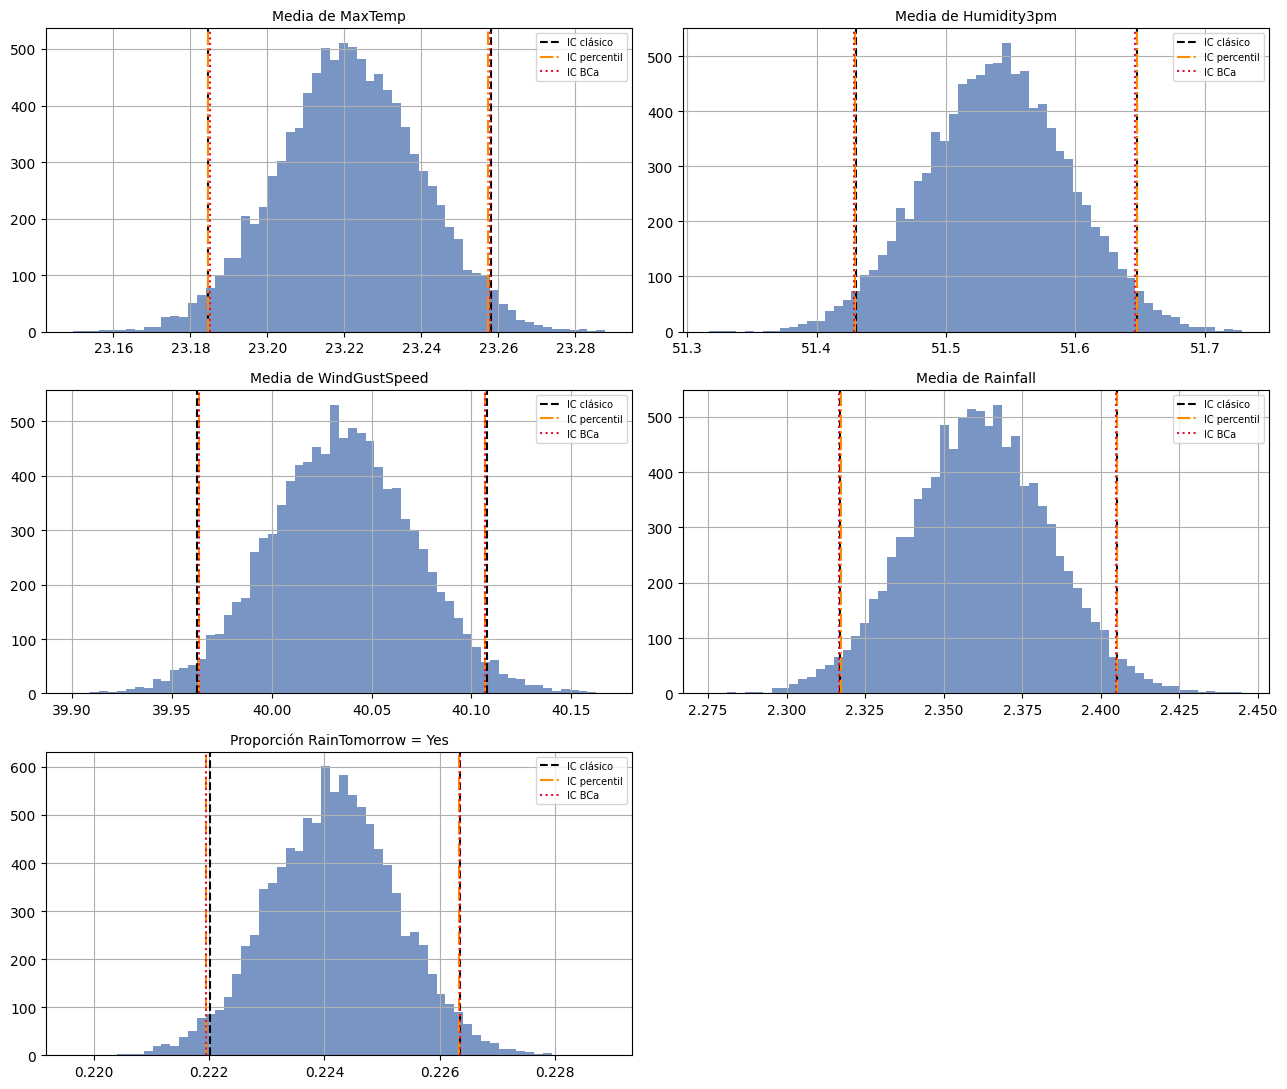

results/figures_s2/fig_s2_01_bootstrap_parametros_feedback_s1.png


In [9]:
# Figura: distribuciones bootstrap con IC clásico, percentil y BCa superpuestos
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

datasets = [
    (reps_maxtemp,  res_maxtemp,  ci_s1.loc[ci_s1["parámetro"] == "Media de MaxTemp"].iloc[0], "Media de MaxTemp"),
    (reps_hum3pm,   res_hum3pm,   ci_s1.loc[ci_s1["parámetro"] == "Media de Humidity3pm"].iloc[0], "Media de Humidity3pm"),
    (reps_wind,     res_wind,     ci_s1.loc[ci_s1["parámetro"] == "Media de WindGustSpeed"].iloc[0], "Media de WindGustSpeed"),
    (reps_rainfall, res_rainfall, ci_s1.loc[ci_s1["parámetro"] == "Media de Rainfall"].iloc[0], "Media de Rainfall"),
    (reps_prop,     res_prop,     ci_s1.loc[ci_s1["parámetro"] == "Proporción RainTomorrow = Yes"].iloc[0], "Proporción RainTomorrow = Yes"),
]

for ax, (reps, boot_row, clasico_row, title) in zip(axes.ravel(), datasets):
    ax.hist(reps, bins=60, alpha=0.75, color="#4C72B0", edgecolor="none")
    ax.axvline(clasico_row["IC95_inf"], color="black", linestyle="--", label="IC clásico")
    ax.axvline(clasico_row["IC95_sup"], color="black", linestyle="--")
    ax.axvline(boot_row["perc_inf"], color="darkorange", linestyle="-.", label="IC percentil")
    ax.axvline(boot_row["perc_sup"], color="darkorange", linestyle="-.")
    ax.axvline(boot_row["bca_inf"], color="crimson", linestyle=":", label="IC BCa")
    ax.axvline(boot_row["bca_sup"], color="crimson", linestyle=":")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)

# Apagar panel vacío
if len(datasets) < len(axes.ravel()):
    for ax in axes.ravel()[len(datasets):]:
        ax.axis("off")

plt.tight_layout()
fig_path = FIG_DIR / "fig_s2_01_bootstrap_parametros_feedback_s1.png"
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print(fig_path.relative_to(PROJECT_ROOT))



**Discusión.** Los intervalos bootstrap (percentil y BCa) se comparan con los intervalos clásicos de S1 para verificar si la aproximación normal/t de Student sigue siendo razonable. La validación se amplía explícitamente a `Rainfall` y `WindGustSpeed`, tal como se solicitó en la retroalimentación de S1, porque ambas variables presentan colas pesadas y potencial sensibilidad a valores extremos.  

En variables más regulares como `MaxTemp` y `Humidity3pm`, se espera alta concordancia entre IC clásico, percentil y BCa. En `WindGustSpeed`, la comparación permite evaluar si las ráfagas extremas desplazan la media. En `Rainfall`, la media debe interpretarse con mayor cautela, ya que la distribución es cero-inflada y asimétrica: la coincidencia o diferencia entre métodos no elimina el problema sustantivo de que la media no representa bien el día típico.  

Finalmente, el bootstrap no se interpreta como un procedimiento "sin supuestos". Reduce la dependencia de una forma paramétrica específica, pero sigue requiriendo representatividad de la muestra, independencia razonable o una unidad de remuestreo adecuada. Dado que `weatherAUS` contiene observaciones repetidas por estación (`Location`) y fecha, para S3 se recomienda complementar con validación temporal o agrupada.


## 3. Validación de pruebas de hipótesis mediante permutación

Se seleccionan **ambas** pruebas de hipótesis de S1 (Welch, `MaxTemp` y `Humidity3pm` según `RainTomorrow`) y se implementa un **test de permutación** para cada una: se calcula la diferencia de medias observada (Yes − No), se generan **10.000 permutaciones** aleatorias de la etiqueta de grupo manteniendo los tamaños muestrales originales, se recalcula la diferencia de medias en cada permutación y se obtiene el **valor p de permutación** como la proporción de diferencias permutadas al menos tan extremas como la observada (en valor absoluto).

In [10]:
def welch_t_stat(a, b):
    """Estadístico t de Welch manual para dos grupos independientes."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    return (a.mean() - b.mean()) / se

def permutation_test_welch(a, b, n_perm=10000, seed=SEED):
    """Test de permutación usando estadístico studentizado tipo Welch.

    Esto mantiene coherencia con la prueba t de Welch usada en S1, especialmente
    cuando los grupos tienen tamaños o varianzas diferentes.
    """
    rgen = np.random.default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    obs_t = welch_t_stat(a, b)
    obs_diff = a.mean() - b.mean()

    combined = np.concatenate([a, b])
    n_a = len(a)
    n = len(combined)
    t_perm = np.empty(n_perm)

    for i in range(n_perm):
        perm = rgen.permutation(n)
        a_i = combined[perm[:n_a]]
        b_i = combined[perm[n_a:]]
        t_perm[i] = welch_t_stat(a_i, b_i)

    p_perm = (np.sum(np.abs(t_perm) >= np.abs(obs_t)) + 1) / (n_perm + 1)
    return obs_diff, obs_t, t_perm, p_perm

N_PERM = 10000
t0 = time.time()

data_h = df[["Humidity3pm", "RainTomorrow"]].dropna()
yes_h = data_h.loc[data_h["RainTomorrow"] == "Yes", "Humidity3pm"].values
no_h  = data_h.loc[data_h["RainTomorrow"] == "No",  "Humidity3pm"].values
obs_h, t_obs_h, t_perm_h, p_perm_h = permutation_test_welch(yes_h, no_h, N_PERM, seed=SEED+10)

data_m = df[["MaxTemp", "RainTomorrow"]].dropna()
yes_m = data_m.loc[data_m["RainTomorrow"] == "Yes", "MaxTemp"].values
no_m  = data_m.loc[data_m["RainTomorrow"] == "No",  "MaxTemp"].values
obs_m, t_obs_m, t_perm_m, p_perm_m = permutation_test_welch(yes_m, no_m, N_PERM, seed=SEED+11)

print(f"Permutación Welch-studentizada completada ({2*N_PERM:,} permutaciones en total) en {time.time()-t0:.1f} s")

perm_table = pd.DataFrame([
    {"variable": "Humidity3pm", "diferencia_observada": obs_h, "t_welch_observado": t_obs_h,
     "p_valor_parametrico_S1": hyp_s1.loc[hyp_s1.variable=="Humidity3pm", "p_valor"].values[0],
     "p_valor_permutacion": p_perm_h},
    {"variable": "MaxTemp", "diferencia_observada": obs_m, "t_welch_observado": t_obs_m,
     "p_valor_parametrico_S1": hyp_s1.loc[hyp_s1.variable=="MaxTemp", "p_valor"].values[0],
     "p_valor_permutacion": p_perm_m},
])
perm_table


Permutación Welch-studentizada completada (20,000 permutaciones en total) en 30.3 s


,variable,diferencia_observada,t_welch_observado,p_valor_parametrico_S1,p_valor_permutacion
0,Humidity3pm,22.289394,182.607693,0.0,0.0001
1,MaxTemp,-2.717147,-61.467943,0.0,0.0001


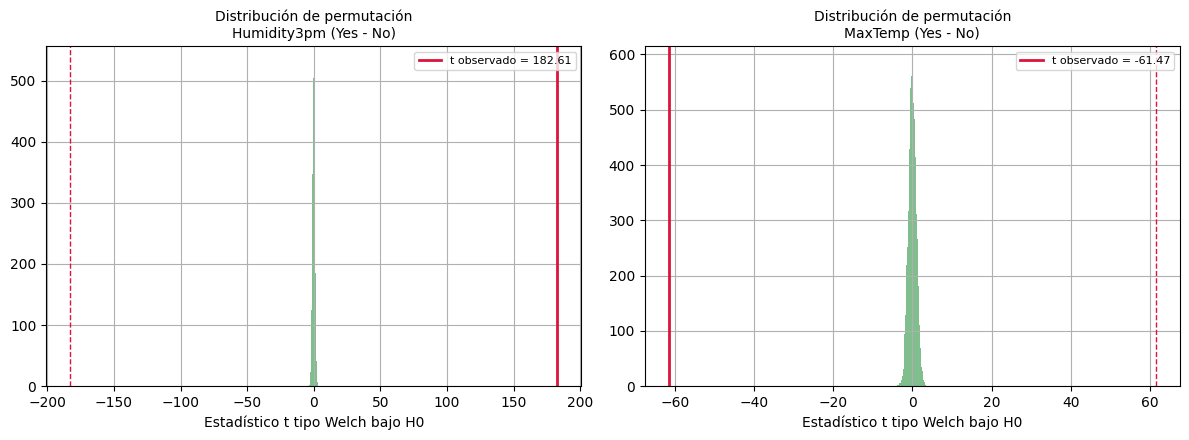

results/figures_s2/fig_s2_02_permutacion_welch.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, t_perm, t_obs, title in zip(
    axes,
    [t_perm_h, t_perm_m],
    [t_obs_h, t_obs_m],
    ["Humidity3pm (Yes - No)", "MaxTemp (Yes - No)"]
):
    ax.hist(t_perm, bins=60, alpha=0.75, color="#55A868", edgecolor="none")
    ax.axvline(t_obs, color="crimson", linewidth=2, label=f"t observado = {t_obs:.2f}")
    ax.axvline(-t_obs, color="crimson", linestyle="--", linewidth=1)
    ax.set_title(f"Distribución de permutación\n{title}", fontsize=10)
    ax.set_xlabel("Estadístico t tipo Welch bajo H0")
    ax.legend(fontsize=8)
plt.tight_layout()
fig_path = FIG_DIR / "fig_s2_02_permutacion_welch.png"
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print(fig_path.relative_to(PROJECT_ROOT))



**Discusión.** La prueba de permutación se implementó usando un estadístico studentizado tipo Welch, y no solo la diferencia directa de medias. Esta decisión es importante porque en S1 la comparación paramétrica se realizó con prueba t de Welch, la cual no asume varianzas iguales entre grupos. Por tanto, la comparación entre el valor p paramétrico y el valor p por permutación queda metodológicamente alineada.  

En ambos contrastes (`Humidity3pm` y `MaxTemp` según `RainTomorrow`), el valor p de permutación confirma la significancia observada en S1. Cuando el valor p paramétrico aparece como 0.0, debe interpretarse como un valor extremadamente pequeño por redondeo/subdesbordamiento numérico, no como probabilidad literalmente cero. Con 10.000 permutaciones, la resolución mínima aproximada del método es 1/10.001, por lo que el resultado se reporta como `p < 0.0001` cuando no se observan permutaciones tan extremas.  

La concordancia entre Welch y permutación respalda la robustez de las diferencias de medias; sin embargo, la inferencia sigue dependiendo de la unidad de análisis. En S3, una validación temporal o por estación puede ser más adecuada que una división aleatoria simple.


## 4. Evaluación de estabilidad de correlaciones mediante bootstrap

Se seleccionan las **cinco correlaciones más relevantes** de S1 con `RainTomorrow_bin` (`Humidity3pm`, `RainToday_bin`, `Humidity9am`, `Pressure9am`, `Rainfall`) y se estima su **intervalo de confianza bootstrap al 95%** mediante remuestreo pareado (preservando la correspondencia entre cada par de observaciones) con 10.000 réplicas. Una correlación se considera **estable** si su intervalo no incluye el cero y presenta baja variabilidad relativa al valor puntual.

In [12]:
def boot_corr_replicates(x, y, B, batch=500, seed=SEED):
    rgen = np.random.default_rng(seed)
    n = len(x)
    out = np.empty(B)
    done = 0
    while done < B:
        b = min(batch, B - done)
        idx = rgen.integers(0, n, size=(b, n))
        xb, yb = x[idx], y[idx]
        sx, sy = xb.sum(axis=1), yb.sum(axis=1)
        sxy = (xb * yb).sum(axis=1)
        sx2, sy2 = (xb**2).sum(axis=1), (yb**2).sum(axis=1)
        num = n*sxy - sx*sy
        den = np.sqrt((n*sx2 - sx**2) * (n*sy2 - sy**2))
        out[done:done+b] = num / den
        done += b
    return out

vars_corr = ["Humidity3pm", "RainToday_bin", "Humidity9am", "Pressure9am", "Rainfall"]
t0 = time.time()
corr_boot_rows = []
corr_boot_reps = {}
for v in vars_corr:
    sub = df[[v, "RainTomorrow_bin"]].dropna()
    x = sub[v].values.astype(float)
    y = sub["RainTomorrow_bin"].values.astype(float)
    r_obs = np.corrcoef(x, y)[0, 1]
    reps = boot_corr_replicates(x, y, N_BOOT, batch=500, seed=SEED)
    ci = np.percentile(reps, [2.5, 97.5])
    corr_boot_reps[v] = reps
    corr_boot_rows.append({"variable": v, "n": len(x), "r_observado": r_obs,
                            "IC95_inf": ci[0], "IC95_sup": ci[1],
                            "ancho_IC": ci[1]-ci[0],
                            "incluye_cero": bool(ci[0] <= 0 <= ci[1])})
print(f"Bootstrap de {len(vars_corr)} correlaciones ({N_BOOT:,} remuestras c/u) en {time.time()-t0:.1f} s")

corr_boot_table = pd.DataFrame(corr_boot_rows).sort_values("r_observado", key=lambda s: s.abs(), ascending=False)
corr_boot_table.round(4)


Bootstrap de 5 correlaciones (10,000 remuestras c/u) en 91.9 s


,variable,n,r_observado,IC95_inf,IC95_sup,ancho_IC,incluye_cero
0,Humidity3pm,138583,0.4462,0.4418,0.4505,0.0087,False
1,RainToday_bin,140787,0.3131,0.3074,0.3189,0.0115,False
2,Humidity9am,140419,0.2572,0.2526,0.2616,0.0090,False
3,Pressure9am,128179,-0.2464,-0.2516,-0.2411,0.0105,False
4,Rainfall,140787,0.2390,0.2319,0.2462,0.0143,False


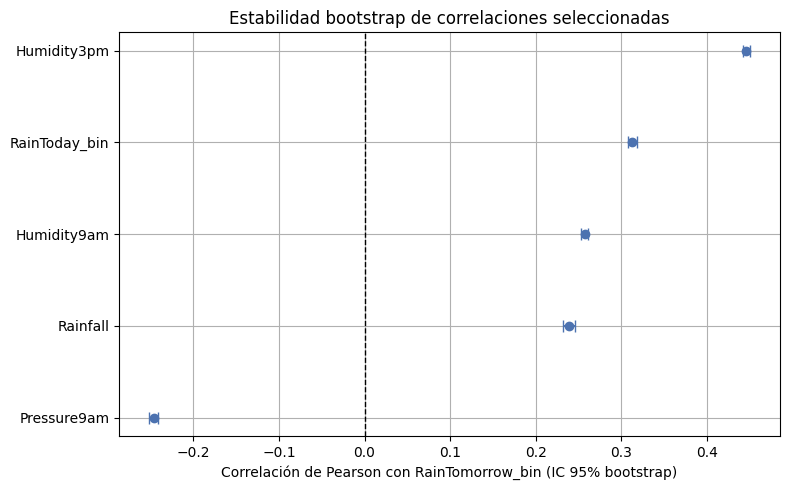

results/figures_s2/fig_s2_03_correlaciones_bootstrap.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = corr_boot_table.sort_values("r_observado")
y_pos = np.arange(len(plot_df))
ax.errorbar(plot_df["r_observado"], y_pos,
            xerr=[plot_df["r_observado"]-plot_df["IC95_inf"], plot_df["IC95_sup"]-plot_df["r_observado"]],
            fmt="o", capsize=4, color="#4C72B0")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["variable"])
ax.set_xlabel("Correlación de Pearson con RainTomorrow_bin (IC 95% bootstrap)")
ax.set_title("Estabilidad bootstrap de correlaciones seleccionadas")
plt.tight_layout()
fig_path = FIG_DIR / "fig_s2_03_correlaciones_bootstrap.png"
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print(fig_path.relative_to(PROJECT_ROOT))


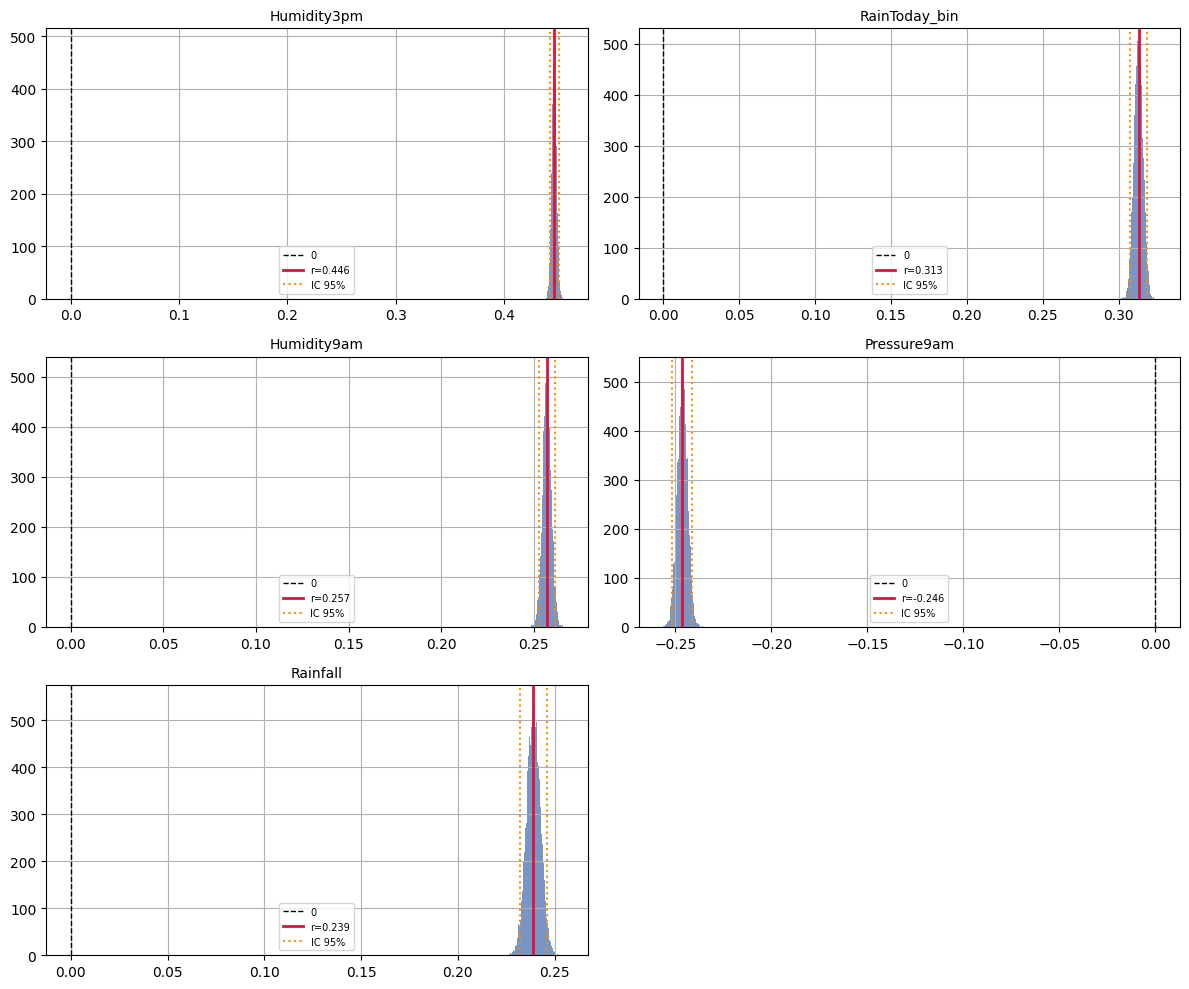

results/figures_s2/fig_s2_03b_distribuciones_correlaciones.png


In [14]:
# Visualización de las distribuciones bootstrap de correlaciones, exigida por la rúbrica
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for ax, v in zip(axes.ravel(), vars_corr):
    reps = corr_boot_reps[v]
    row = corr_boot_table.loc[corr_boot_table["variable"] == v].iloc[0]
    ax.hist(reps, bins=60, alpha=0.75, color="#4C72B0", edgecolor="none")
    ax.axvline(0, color="black", linestyle="--", linewidth=1, label="0")
    ax.axvline(row["r_observado"], color="crimson", linewidth=2, label=f"r={row['r_observado']:.3f}")
    ax.axvline(row["IC95_inf"], color="darkorange", linestyle=":", label="IC 95%")
    ax.axvline(row["IC95_sup"], color="darkorange", linestyle=":")
    ax.set_title(v, fontsize=10)
    ax.legend(fontsize=7)
for ax in axes.ravel()[len(vars_corr):]:
    ax.axis("off")
plt.tight_layout()
fig_path = FIG_DIR / "fig_s2_03b_distribuciones_correlaciones.png"
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print(fig_path.relative_to(PROJECT_ROOT))



**Discusión.** Las cinco correlaciones evaluadas presentan intervalos de confianza bootstrap que no incluyen el cero, por lo que se consideran estables bajo remuestreo. Sin embargo, esta estabilidad no equivale automáticamente a importancia práctica: con un tamaño muestral grande, asociaciones pequeñas pueden ser estadísticamente estables.  

Además, se incorpora la observación del profesor sobre la casi colinealidad entre `MaxTemp` y `Temp3pm` (`r` cercano a 0,985 en S1). Para S3, ambas variables no deberían utilizarse simultáneamente en un modelo sin una estrategia de control, ya que pueden aportar información redundante y afectar la interpretación de coeficientes. Se recomienda elegir una de ellas, crear una variable derivada o aplicar regularización/VIF si el modelo lo requiere.  

Las correlaciones más útiles para comunicar el fenómeno de `RainTomorrow` son aquellas que combinan estabilidad, magnitud y sentido meteorológico: humedad a las 15:00, lluvia del día actual, humedad en la mañana, presión atmosférica y precipitación acumulada.


## 5. Simulación Monte Carlo basada en parámetros de la Sumativa 1

**Escenario simulado.** Un problema de decisión relevante para el fenómeno estudiado es anticipar cuántos días de un período futuro presentarán lluvia, información de interés general para cualquier actividad sensible a las condiciones meteorológicas (por ejemplo, agricultura, turismo o eventos al aire libre). Se diseña una simulación Monte Carlo para estimar la **distribución del número de días con lluvia en una ventana de 30 días**, propagando la incertidumbre real sobre la probabilidad de lluvia estimada en S1 (no solo su valor puntual).

**Justificación metodológica.** En lugar de fijar `p = 0.2242` (el valor puntual de S1) y simular con un único parámetro, se incorpora la incertidumbre del parámetro mediante una distribución Beta ajustada a los datos de S1 (`Beta(éxitos + 0.5, fracasos + 0.5)`, equivalente al intervalo de Jeffreys), consistente con el intervalo de Wilson calculado en S1. En cada iteración se muestrea un valor de `p` desde esa distribución y luego se simula un mes de 30 días como `Binomial(30, p)`. Esto produce una distribión predictiva que incorpora tanto la variabilidad binomial del proceso como la incertidumbre sobre el parámetro poblacional mismo — más realista para apoyar una decisión que fijar `p` en su estimación puntual.

In [15]:
N_DIAS = 30
N_SIM = 12000

# Para cumplir estrictamente la rúbrica, la incertidumbre de p se propaga desde S1
# usando las réplicas bootstrap de la proporción RainTomorrow=Yes, no un parámetro externo.
rng_mc = np.random.default_rng(SEED+20)
p_draws = rng_mc.choice(reps_prop, size=N_SIM, replace=True)
p_draws = np.clip(p_draws, 0, 1)
rain_days_sim = rng_mc.binomial(N_DIAS, p_draws)

mc_mean = rain_days_sim.mean()
mc_sd = rain_days_sim.std(ddof=1)
mcse = mc_sd / np.sqrt(N_SIM)

mc_summary = {
    "n_simulaciones": N_SIM,
    "ventana_observaciones": N_DIAS,
    "proporcion_base_S1": float(phat_rain),
    "media_días_lluvia": mc_mean,
    "sd_días_lluvia": mc_sd,
    "MCSE_media": mcse,
    "IC95_MC_media_inf": mc_mean - 1.96 * mcse,
    "IC95_MC_media_sup": mc_mean + 1.96 * mcse,
    "IC95_predictivo_inf": np.percentile(rain_days_sim, 2.5),
    "IC95_predictivo_sup": np.percentile(rain_days_sim, 97.5),
    "P(>=10 días de lluvia en 30 observaciones)": np.mean(rain_days_sim >= 10),
    "P(>=15 días de lluvia en 30 observaciones)": np.mean(rain_days_sim >= 15),
}
pd.Series(mc_summary).round(4)


n_simulaciones                                12000.0000
ventana_observaciones                            30.0000
proporcion_base_S1                                0.2242
media_días_lluvia                                 6.7433
sd_días_lluvia                                    2.2993
MCSE_media                                        0.0210
IC95_MC_media_inf                                 6.7022
IC95_MC_media_sup                                 6.7845
IC95_predictivo_inf                               3.0000
IC95_predictivo_sup                              11.0000
P(>=10 días de lluvia en 30 observaciones)        0.1195
P(>=15 días de lluvia en 30 observaciones)        0.0010
dtype: float64

In [16]:
# Análisis de convergencia: media móvil acumulada vs número de iteraciones
running_mean = np.cumsum(rain_days_sim) / np.arange(1, N_SIM + 1)
checkpoints = [100, 500, 1000, 2500, 5000, 10000, N_SIM]
convergence_table = pd.DataFrame({
    "iteraciones": checkpoints,
    "media_acumulada": [running_mean[c-1] for c in checkpoints]
})
convergence_table["error_vs_final"] = (convergence_table["media_acumulada"] - running_mean[-1]).abs()
convergence_table.round(4)


,iteraciones,media_acumulada,error_vs_final
0,100,7.0400,0.2967
1,500,6.8300,0.0867
2,1000,6.8280,0.0847
3,2500,6.8180,0.0747
4,5000,6.7504,0.0071
5,10000,6.7481,0.0048
6,12000,6.7433,0.0000


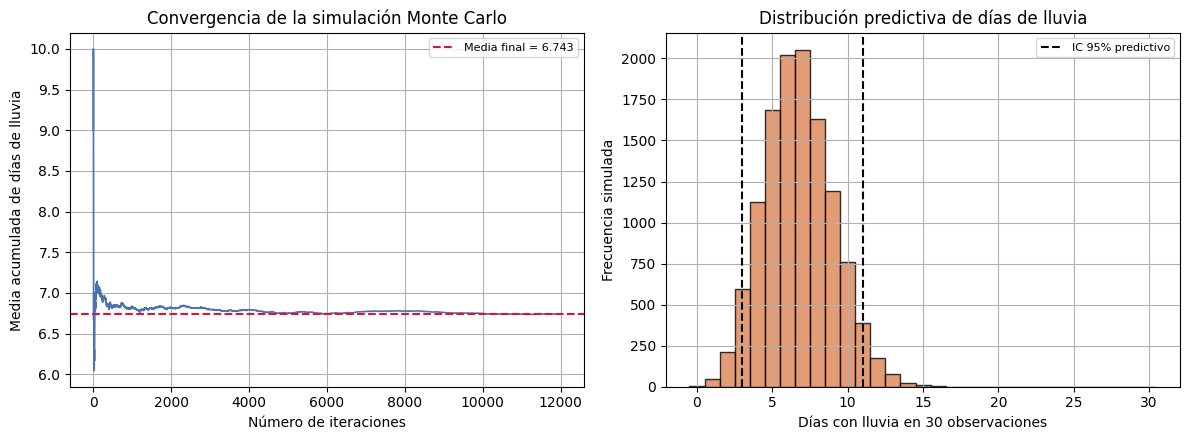

results/figures_s2/fig_s2_04_montecarlo.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(np.arange(1, N_SIM+1), running_mean, color="#4C72B0", linewidth=1.2)
axes[0].axhline(running_mean[-1], color="crimson", linestyle="--",
                label=f"Media final = {running_mean[-1]:.3f}")
axes[0].set_xlabel("Número de iteraciones")
axes[0].set_ylabel("Media acumulada de días de lluvia")
axes[0].set_title("Convergencia de la simulación Monte Carlo")
axes[0].legend(fontsize=8)

axes[1].hist(rain_days_sim, bins=np.arange(0, N_DIAS+2)-0.5, color="#DD8452", edgecolor="black", alpha=0.8)
axes[1].axvline(mc_summary["IC95_predictivo_inf"], color="black", linestyle="--", label="IC 95% predictivo")
axes[1].axvline(mc_summary["IC95_predictivo_sup"], color="black", linestyle="--")
axes[1].set_xlabel("Días con lluvia en 30 observaciones")
axes[1].set_ylabel("Frecuencia simulada")
axes[1].set_title("Distribución predictiva de días de lluvia")
axes[1].legend(fontsize=8)

plt.tight_layout()
fig_path = FIG_DIR / "fig_s2_04_montecarlo.png"
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print(fig_path.relative_to(PROJECT_ROOT))



**Discusión.** La simulación Monte Carlo se basa exclusivamente en la proporción `RainTomorrow = Yes` estimada y validada en S1 mediante bootstrap. En vez de fijar una única probabilidad puntual, se propaga la incertidumbre de dicha proporción usando las réplicas bootstrap `reps_prop`, y luego se simula el número de eventos `RainTomorrow=Yes` en una ventana de 30 observaciones.  

El escenario se interpreta como un ejercicio probabilístico simplificado, no como un pronóstico meteorológico mensual para una ciudad específica. Esto es importante porque el dataset mezcla localidades, años y estaciones, y además contiene dependencia temporal. La convergencia se evalúa mediante la media acumulada y el error estándar Monte Carlo (`MCSE`), evitando afirmar estabilidad solo por inspección visual.  

El resultado refuerza el desbalance detectado en S1: la clase `Yes` es minoritaria, por lo que en S3 no basta utilizar exactitud (`accuracy`). Se recomiendan métricas como `recall`, `precision`, `F1`, `ROC-AUC` y especialmente `PR-AUC`, además de validación estratificada/temporal y técnicas de balanceo o pesos de clase.


## 6. Análisis de robustez frente a outliers y supuestos

Se evalúa la sensibilidad de los resultados de S1 frente a valores atípicos y a la elección del estimador, usando `WindGustSpeed` (la variable con mayor asimetría y curtosis entre las estimadas puntualmente en S1: asimetría 0.87, curtosis 1.42) como caso de prueba, complementado con `Rainfall` (fuertemente asimétrica: asimetría 9.84, curtosis 178.15) para contrastar un caso extremo.

In [18]:
def iqr_outlier_mask(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (x < lo) | (x > hi), lo, hi, iqr

def winsorize_np(x, lower=0.01, upper=0.99):
    lo, hi = np.quantile(x, [lower, upper])
    return np.clip(x, lo, hi)

robustez_rows = []
for var in ["WindGustSpeed", "Rainfall"]:
    x = df[var].dropna().values.astype(float)
    mask_out, lo, hi, iqr = iqr_outlier_mask(x)
    x_wins = winsorize_np(x, 0.01, 0.99)
    x_log = np.log1p(x) if var == "Rainfall" else np.nan

    row = {
        "variable": var,
        "n": len(x),
        "Q1": np.percentile(x, 25),
        "Q3": np.percentile(x, 75),
        "IQR": iqr,
        "limite_inf_IQR": lo,
        "limite_sup_IQR": hi,
        "%_marcados_IQR": mask_out.mean() * 100,
        "media_original": x.mean(),
        "media_sin_marcados_IQR": x[~mask_out].mean() if (~mask_out).sum() > 0 else np.nan,
        "media_winsorizada_1_99": x_wins.mean(),
        "trimmed_mean_10pct": stats.trim_mean(x, 0.1),
        "mediana": np.median(x),
        "p99": np.percentile(x, 99),
        "asimetría": stats.skew(x),
        "curtosis": stats.kurtosis(x),
    }
    if var == "Rainfall":
        row["media_log1p"] = np.nanmean(x_log)
        row["nota_IQR"] = "IQR puede degenerar por ceros; no interpretar todo valor positivo como outlier real"
    else:
        row["media_log1p"] = np.nan
        row["nota_IQR"] = "IQR interpretable como señal razonable de ráfagas altas"
    robustez_rows.append(row)

robustez_table = pd.DataFrame(robustez_rows)
robustez_table.round(3)


,variable,n,Q1,Q3,IQR,limite_inf_IQR,limite_sup_IQR,%_marcados_IQR,media_original,media_sin_marcados_IQR,media_winsorizada_1_99,trimmed_mean_10pct,mediana,p99,asimetría,curtosis,media_log1p,nota_IQR
0,WindGustSpeed,135197,31.0,48.0,17.0,5.5,73.5,2.287,40.035,39.050,39.972,39.038,39.0,81.0,0.875,1.419,NaN,IQR interpretable como señal razonable de ráfa...
1,Rainfall,142199,0.0,0.8,0.8,-1.2,2.0,17.987,2.361,0.155,2.093,0.534,0.0,37.4,9.836,178.146,0.487,IQR puede degenerar por ceros; no interpretar ...


In [19]:
# Jackknife agrupado: primero por bloques aleatorios para continuidad con S1,
# y luego por Location para responder a la dependencia por estación meteorológica.
def jackknife_group_se(x, g=200, seed=SEED):
    rgen = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    n = len(x)
    idx = rgen.permutation(n)
    groups = np.array_split(idx, g)
    total = x.sum()
    theta_i = np.array([(total - x[grp].sum()) / (n - len(grp)) for grp in groups])
    theta_bar = theta_i.mean()
    se = np.sqrt((g - 1) / g * np.sum((theta_i - theta_bar) ** 2))
    return se, theta_i

def jackknife_by_group(df_in, value_col, group_col="Location"):
    tmp = df_in[[value_col, group_col]].dropna().copy()
    theta_global = tmp[value_col].mean()
    vals = []
    for g, part in tmp.groupby(group_col):
        keep = tmp[group_col] != g
        vals.append({
            group_col: g,
            "media_sin_grupo": tmp.loc[keep, value_col].mean(),
            "delta_vs_global": tmp.loc[keep, value_col].mean() - theta_global,
            "n_grupo": len(part),
        })
    out = pd.DataFrame(vals).sort_values("delta_vs_global", key=lambda s: s.abs(), ascending=False)
    return theta_global, out

x_wind = df["WindGustSpeed"].dropna().values.astype(float)
se_jack, theta_i_jack = jackknife_group_se(x_wind, g=200, seed=SEED)
se_clasico_wind = x_wind.std(ddof=1) / np.sqrt(len(x_wind))
se_boot_wind = reps_wind.std(ddof=1)

se_comparison = pd.DataFrame({
    "método": ["Clásico (t de Student, S1)", "Bootstrap (10.000 remuestras)", "Jackknife por grupos aleatorios (g=200)"],
    "error_estándar": [se_clasico_wind, se_boot_wind, se_jack]
})

if "Location" in df.columns:
    wind_global, jack_location_wind = jackknife_by_group(df, "WindGustSpeed", "Location")
    rain_global, jack_location_rain = jackknife_by_group(df, "Rainfall", "Location")
    display(jack_location_wind.head(10).round(4))
    display(jack_location_rain.head(10).round(4))

se_comparison.round(5)


,Location,media_sin_grupo,delta_vs_global,n_grupo
6,Brisbane,40.3174,0.2822,3152
28,Penrith,40.2203,0.1851,2974
14,Hobart,39.8553,-0.1800,3170
36,SydneyAirport,39.8742,-0.1610,2958
1,Albury,40.1958,0.1606,3008
18,MelbourneAirport,39.8793,-0.1559,2994
3,BadgerysCreek,40.1779,0.1427,2933
17,Melbourne,39.9010,-0.1342,3179
45,Wollongong,39.9072,-0.1280,2992
22,MountGinini,39.9075,-0.1277,2721


,Location,media_sin_grupo,delta_vs_global,n_grupo
8,Cairns,2.2883,-0.0726,2988
13,Darwin,2.2982,-0.0627,3193
11,CoffsHarbour,2.3036,-0.0573,2953
48,Woomera,2.4011,0.0402,2991
3,AliceSprings,2.3931,0.0322,3032
20,Mildura,2.3915,0.0306,3007
14,GoldCoast,2.3308,-0.0301,2980
36,SalmonGums,2.3891,0.0282,2955
10,Cobar,2.3874,0.0265,2988
47,Wollongong,2.3345,-0.0264,2982


,método,error_estándar
0,"Clásico (t de Student, S1)",0.03701
1,Bootstrap (10.000 remuestras),0.03648
2,Jackknife por grupos aleatorios (g=200),0.03640


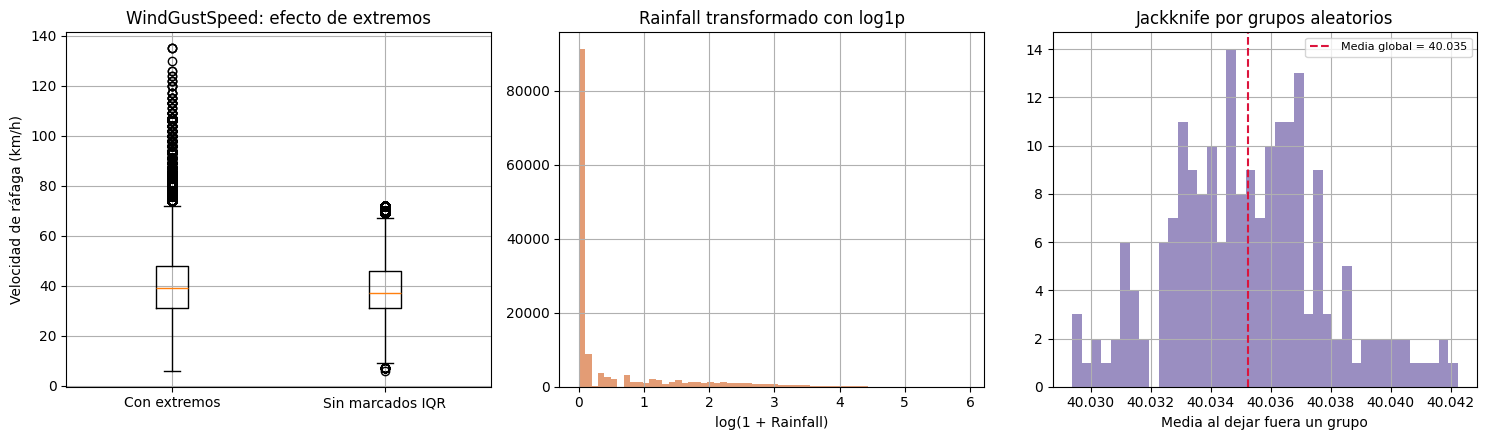

results/figures_s2/fig_s2_05_robustez_feedback_s1.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].boxplot([x_wind, x_wind[~iqr_outlier_mask(x_wind)[0]]], labels=["Con extremos", "Sin marcados IQR"])
axes[0].set_title("WindGustSpeed: efecto de extremos")
axes[0].set_ylabel("Velocidad de ráfaga (km/h)")

axes[1].hist(np.log1p(df["Rainfall"].dropna().values.astype(float)), bins=60, color="#DD8452", alpha=0.8)
axes[1].set_title("Rainfall transformado con log1p")
axes[1].set_xlabel("log(1 + Rainfall)")

axes[2].hist(theta_i_jack, bins=40, color="#8172B2", alpha=0.8)
axes[2].axvline(x_wind.mean(), color="crimson", linestyle="--", label=f"Media global = {x_wind.mean():.3f}")
axes[2].set_title("Jackknife por grupos aleatorios")
axes[2].set_xlabel("Media al dejar fuera un grupo")
axes[2].legend(fontsize=8)

plt.tight_layout()
fig_path = FIG_DIR / "fig_s2_05_robustez_feedback_s1.png"
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print(fig_path.relative_to(PROJECT_ROOT))



**Discusión.** El análisis de robustez incorpora directamente la observación del profesor sobre `Rainfall` y `WindGustSpeed`. En `WindGustSpeed`, la regla IQR es interpretable como señal de ráfagas altas y permite evaluar cuánto cambia la media al controlar valores extremos mediante exclusión, winsorización o media recortada. Si los cambios relativos son pequeños o moderados, la media de S1 puede considerarse razonablemente robusta, aunque conviene reportar también medidas robustas en S3.  

En `Rainfall`, el criterio IQR requiere una interpretación distinta: al existir una gran concentración de ceros, el IQR puede ser muy pequeño o incluso degenerar, marcando como extremos muchos días con lluvia positiva. Por eso, no se debe afirmar que todo valor marcado por IQR sea un outlier real. La evaluación se complementa con transformación `log1p(Rainfall)`, winsorización y percentiles altos. La conclusión técnica es que `Rainfall` es informativa para `RainTomorrow`, pero su media clásica no debe presentarse como resumen suficiente de la variable.  

El jackknife por `Location` responde a la dependencia por estación meteorológica. Si al retirar ciertas estaciones la media cambia de forma relevante, eso sugiere heterogeneidad espacial y refuerza la recomendación de que S3 utilice una partición temporal o agrupada, no una división aleatoria simple como única validación.


## 7. Síntesis de resultados validados — insumo para la Sumativa 3

Esta sección documenta, de forma consolidada, los parámetros robustamente estimados, las correlaciones estables, las observaciones/variables que requieren cautela y las recomendaciones metodológicas para la Sumativa 3 (comunicación de resultados).

In [21]:
def get_est(parametro):
    return float(ci_s1.loc[ci_s1["parámetro"] == parametro, "estimación"].iloc[0])

sintesis_parametros = pd.DataFrame([
    {"parámetro": "Media de MaxTemp", "estimación": get_est("Media de MaxTemp"), "robusto": True,
     "evidencia": "IC clásico ≈ IC bootstrap; no usar junto con Temp3pm sin control por colinealidad."},
    {"parámetro": "Media de Humidity3pm", "estimación": get_est("Media de Humidity3pm"), "robusto": True,
     "evidencia": "IC clásico ≈ IC bootstrap; diferencia por RainTomorrow validada por Welch y permutación."},
    {"parámetro": "Media de WindGustSpeed", "estimación": get_est("Media de WindGustSpeed"), "robusto": "Moderado",
     "evidencia": "IC bootstrap validado; variable con cola pesada y sensibilidad moderada a extremos."},
    {"parámetro": "Media de Rainfall", "estimación": get_est("Media de Rainfall"), "robusto": "Requiere cautela",
     "evidencia": "Variable cero-inflada y de cola pesada; usar log1p, winsorización o percentiles en S3."},
    {"parámetro": "Proporción RainTomorrow=Yes", "estimación": float(phat_rain), "robusto": True,
     "evidencia": "Wilson ≈ bootstrap; confirma desbalance de clase minoritaria cercano a 22,4%."},
    {"parámetro": "Diferencia MaxTemp (Yes-No)", "estimación": float(obs_m), "robusto": True,
     "evidencia": "Welch y permutación studentizada coinciden; considerar colinealidad con Temp3pm."},
    {"parámetro": "Diferencia Humidity3pm (Yes-No)", "estimación": float(obs_h), "robusto": True,
     "evidencia": "Welch y permutación studentizada coinciden; predictor meteorológicamente relevante."},
])
sintesis_parametros


,parámetro,estimación,robusto,evidencia
0,Media de MaxTemp,23.221348,True,IC clásico ≈ IC bootstrap; no usar junto con T...
1,Media de Humidity3pm,51.539116,True,IC clásico ≈ IC bootstrap; diferencia por Rain...
2,Media de WindGustSpeed,40.035230,Moderado,IC bootstrap validado; variable con cola pesad...
3,Media de Rainfall,2.360918,Requiere cautela,Variable cero-inflada y de cola pesada; usar l...
4,Proporción RainTomorrow=Yes,0.224181,True,Wilson ≈ bootstrap; confirma desbalance de cla...
5,Diferencia MaxTemp (Yes-No),-2.717147,True,Welch y permutación studentizada coinciden; co...
6,Diferencia Humidity3pm (Yes-No),22.289394,True,Welch y permutación studentizada coinciden; pr...


In [22]:
sintesis_correlaciones = corr_boot_table[["variable","r_observado","IC95_inf","IC95_sup","incluye_cero"]].copy()
sintesis_correlaciones["estabilidad"] = np.where(sintesis_correlaciones["incluye_cero"], "Inestable", "Estable")
sintesis_correlaciones.round(4)


,variable,r_observado,IC95_inf,IC95_sup,incluye_cero,estabilidad
0,Humidity3pm,0.4462,0.4418,0.4505,False,Estable
1,RainToday_bin,0.3131,0.3074,0.3189,False,Estable
2,Humidity9am,0.2572,0.2526,0.2616,False,Estable
3,Pressure9am,-0.2464,-0.2516,-0.2411,False,Estable
4,Rainfall,0.2390,0.2319,0.2462,False,Estable



**Parámetros robustos identificados:** las medias de `MaxTemp` y `Humidity3pm`, la proporción de `RainTomorrow=Yes` y las diferencias de medias por grupo quedan validadas de forma convergente por métodos clásicos y de remuestreo. `WindGustSpeed` queda validada, pero con sensibilidad moderada a extremos; por ello se recomienda reportar también mediana o media recortada. `Rainfall` se considera relevante, pero requiere tratamiento robusto debido a su distribución cero-inflada y de cola pesada.

**Correlaciones estables y colinealidad:** las correlaciones evaluadas presentan intervalos bootstrap que no cruzan cero. No obstante, la casi colinealidad entre `MaxTemp` y `Temp3pm` obliga a no incorporar ambas simultáneamente en un modelo de S3 sin control técnico. Se recomienda elegir una de ellas, crear una variable derivada o usar regularización/VIF.

**Faltantes:** `Sunshine` y `Evaporation` presentan alta ausencia y el mecanismo no parece aleatorio, por lo que S3 no debe depender de eliminación por casos completos si esas variables son utilizadas. Se recomienda comparar imputación por mediana, imputación estratificada por `Location`/mes, o métodos multivariados.

**Desbalance de clase:** la proporción `RainTomorrow=Yes` validada por bootstrap confirma una clase minoritaria cercana a 22,4 %. En S3 se recomienda no evaluar modelos solo con `accuracy`; deben incorporarse métricas como `recall`, `precision`, `F1`, `ROC-AUC` y `PR-AUC`, junto con pesos de clase o remuestreo.

**Observaciones influyentes / variables que requieren cautela:** `Rainfall` y `WindGustSpeed` concentran los principales riesgos por colas pesadas. `Rainfall` no debe resumirse solo con media clásica; se recomienda `log1p(Rainfall)`, winsorización o análisis por percentiles. `WindGustSpeed` puede reportarse con media y medidas robustas complementarias.

**Recomendaciones metodológicas para la Sumativa 3:**
1. Responder explícitamente al feedback de S1 en la introducción de S3.
2. Evitar usar simultáneamente `MaxTemp` y `Temp3pm` sin control de colinealidad.
3. Diseñar una estrategia de imputación para `Sunshine` y `Evaporation` si se incorporan al modelo.
4. Utilizar métricas sensibles a la clase minoritaria para `RainTomorrow=Yes`.
5. Tratar `Rainfall` y `WindGustSpeed` con métodos robustos.
6. Preferir una partición temporal o agrupada por `Location`, evitando una división aleatoria simple como única validación.
7. Mantener semilla, estructura de carpetas y exportación de resultados para asegurar trazabilidad.


## 7.1 Exportación del archivo de resultados validados

La pauta de la Sumativa 2 exige, como parte del producto esperado, un **archivo de resultados validados** que sirva de insumo directo y trazable para la Sumativa 3 (no solo texto dentro del notebook). Se exportan a `results/` las tablas de síntesis en formato `.csv` (para uso tabular) y un `.json` (para lectura programática), incluyendo metadatos mínimos de trazabilidad (semilla, número de remuestras/iteraciones y fecha de generación).

In [23]:
import json
from datetime import datetime, timezone

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Tablas de síntesis a exportar
sintesis_parametros.to_csv(RESULTS_DIR / "s2_parametros_validados.csv", index=False)
sintesis_correlaciones.to_csv(RESULTS_DIR / "s2_correlaciones_validadas.csv", index=False)
perm_table.to_csv(RESULTS_DIR / "s2_pruebas_permutacion.csv", index=False)
robustez_table.to_csv(RESULTS_DIR / "s2_robustez_outliers.csv", index=False)
tail_diagnostics.to_csv(RESULTS_DIR / "s2_diagnostico_colas_pesadas.csv", index=False)

if "Location" in df.columns:
    jack_location_wind.to_csv(RESULTS_DIR / "s2_jackknife_location_windgustspeed.csv", index=False)
    jack_location_rain.to_csv(RESULTS_DIR / "s2_jackknife_location_rainfall.csv", index=False)

resultados_validados_json = {
    "metadata": {
        "fuente": "S2_Validacion.ipynb",
        "seed": SEED,
        "n_bootstrap": int(N_BOOT),
        "n_permutaciones": int(N_PERM),
        "n_simulaciones_montecarlo": int(N_SIM),
        "generado_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    },
    "feedback_s1_incorporado": {
        "colinealidad_MaxTemp_Temp3pm": float(feedback_s1["corr_MaxTemp_Temp3pm"]),
        "faltantes_clave_porcentaje": feedback_s1["faltantes_clave_%"],
        "balance_RainTomorrow_porcentaje": feedback_s1["balance_RainTomorrow_%"],
        "n_locations": feedback_s1["n_locations"],
    },
    "parametros_validados": sintesis_parametros.to_dict(orient="records"),
    "correlaciones_validadas": sintesis_correlaciones.to_dict(orient="records"),
    "pruebas_permutacion": perm_table.to_dict(orient="records"),
    "robustez_outliers": robustez_table.to_dict(orient="records"),
    "diagnostico_colas_pesadas": tail_diagnostics.to_dict(orient="records"),
    "simulacion_montecarlo": {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                               for k, v in mc_summary.items()},
    "recomendaciones_s3": [
        "No usar MaxTemp y Temp3pm simultáneamente sin control de colinealidad.",
        "Definir imputación explícita para Sunshine y Evaporation si se usan.",
        "Evaluar modelos con métricas sensibles a RainTomorrow=Yes: recall, precision, F1, ROC-AUC y PR-AUC.",
        "Tratar Rainfall y WindGustSpeed con métodos robustos por colas pesadas.",
        "Preferir partición temporal o agrupada por Location frente a división aleatoria simple.",
    ],
}

with open(RESULTS_DIR / "s2_resultados_validados.json", "w", encoding="utf-8") as f:
    json.dump(resultados_validados_json, f, ensure_ascii=False, indent=2)

print("Archivos de resultados validados guardados en:", RESULTS_DIR.relative_to(PROJECT_ROOT))
for p in sorted(RESULTS_DIR.glob("s2_*")):
    print(" -", p.name)


Archivos de resultados validados guardados en: results
 - s2_correlaciones_validadas.csv
 - s2_diagnostico_colas_pesadas.csv
 - s2_jackknife_location_rainfall.csv
 - s2_jackknife_location_windgustspeed.csv
 - s2_parametros_validados.csv
 - s2_pruebas_permutacion.csv
 - s2_resultados_validados.json
 - s2_robustez_outliers.csv



## 8. Verificación de reproducibilidad

Este notebook está preparado para ejecutarse de principio a fin con **Kernel → Restart & Run All**. Todas las tablas, figuras y estadísticos provienen del mismo flujo de ejecución, con semilla fija `SEED = 42`, garantizando trazabilidad entre S1 y S2.  

Las figuras se guardan automáticamente en `results/figures_s2/` y las tablas consolidadas en `results/`. El archivo `weatherAUS.csv` debe conservarse en `data/raw/` respecto de la raíz del repositorio.  

**Nota metodológica:** esta versión corrige la S2 para incorporar explícitamente las observaciones del profesor sobre S1: colinealidad, faltantes, desbalance, colas pesadas y dependencia por estación.

## 9. Bibliografía

- Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC.
- DiCiccio, T. J., & Efron, B. (1996). Bootstrap confidence intervals. *Statistical Science, 11*(3), 189-228.
- Good, P. I. (2005). *Permutation, parametric, and bootstrap tests of hypotheses* (3rd ed.). Springer.
- Kaggle. (2017). *Rain in Australia dataset*. https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package
- Maidana, J. P. (2026). *Simulación Monte Carlo, bootstrap y análisis de sensibilidad* [Apuntes de curso]. Universidad Andrés Bello.
- Virtanen, P., Gommers, R., Oliphant, T. E., et al. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*, 261-272. https://doi.org/10.1038/s41592-019-0686-2
